# Draft Curve V5: Goals Above Replacement (GAR) with Adaptive Step Priors

**Objective**: Build draft value curves using cumulative Goals Above Replacement (GAR) from Evolving Hockey data, aggregated to 7-year controllable equity windows. Apply Bayesian B-spline model with adaptive step priors to permit sharp drops at the top of the draft while enforcing smoothness in later rounds.

**Metric**: Goals Above Replacement (total, offensive, defensive components)

**Key Innovation**: Adaptive step priors with position $(i)$ in the spline:
- **Picks 1-30 (first 4 steps)**: High variance (σ/2) to allow rapid value decay at impactful picks
- **Picks 30+ (remaining steps)**: Restricted variance (σ/20) to enforce smoothness in low-impact rounds

**Input Files**:
- `EH_gar_sk_stats_regular_2007_2026.csv`: Season-level cumulative GAR data
- `player_lookup_dob_canonical.csv`: Canonical list of players with draft year and IDs
- `data/Scraped/Drafts/draft_YYYY.csv`: Draft picks (2007-2018)

**Output**:
- `draft_curve_gar_total_lookup.csv`: Picks 1-300 with normalized total GAR
- `draft_curve_gar_offensive_lookup.csv`: Picks 1-300 with normalized offensive GAR

In [1]:
import os
import warnings
from datetime import date
from pathlib import Path

# Create a local cache directory right here in your project folder
local_cache = Path(os.getcwd()) / ".python_cache"
local_cache.mkdir(parents=True, exist_ok=True)

# THE FIX: Use .as_posix() to convert Windows backslashes (\) to forward slashes (/)
# This prevents PyTensor's string parser from stripping the slashes out.
posix_cache = local_cache.as_posix()

# 1. Reroute LocalAppData to current working directory
os.environ["LOCALAPPDATA"] = posix_cache

# 2. PyTensor & Numba overrides (safely escaped)
os.environ["PYTENSOR_FLAGS"] = f"base_compiledir={posix_cache}/pytensor"
os.environ["NUMBA_CACHE_DIR"] = f"{posix_cache}/numba"
os.environ["NUMBA_DISABLE_JIT"] = "0"
os.environ["NUMBA_BOUNDSCHECK"] = "0"

# 3. Fix the PyMC / JAX cross-platform warning
os.environ["JAX_PLATFORMS"] = "cpu"

import numba
# Hard-override the config inside the python session using posix paths
numba.config.CACHE_DIR = f"{posix_cache}/numba"

import arviz as az
import pymc as pm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from patsy import dmatrix

# 4. Fix the ArviZ bug locally
try:
    arviz_cache_dir = local_cache / "arviz" / "arviz" / "Cache"
    arviz_cache_dir.mkdir(parents=True, exist_ok=True)
    (arviz_cache_dir / "daily_warning").write_text(date.today().isoformat())
except Exception as e:
    pass

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("✓ All required libraries imported successfully. Caches strictly routed via POSIX paths.")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


✓ All required libraries imported successfully. Caches strictly routed via POSIX paths.


## SECTION 0: LOAD GAR DATA WITH DUPLICATE DETECTION (NEW)

Load Evolving Hockey GAR data, parse seasons, and enforce deduplication on (player_id, season) composite key.

In [ ]:
print("\n" + "="*70)
print("SECTION 0: LOAD GAR DATA WITH DUPLICATE DETECTION")
print("="*70)

import pandas as pd
import numpy as np

# Set base directory
PROJECT_ROOT = Path.cwd().parent.parent

base_dir = PROJECT_ROOT
export_dir = base_dir / "results" / "gar_curve"
export_dir.mkdir(parents=True, exist_ok=True)

# Load GAR data
print("\n1. Loading Evolving Hockey GAR data...")
df_gar_raw = pd.read_csv(base_dir / "data" / "Scraped" / "Evolving_Hockey" / "EH_gar_sk_stats_regular_2007_2026.csv")
print(f"   - Initial load: {len(df_gar_raw):,} rows")
print(f"   - Columns: {df_gar_raw.columns.tolist()}")

# Parse season column: "16-17" format -> end_year (2017)
print("\n2. Parsing season format (YY-YY -> YYYY)...")
def parse_season_to_end_year(season_str):
    """Convert 'YY-YY' format to end year (YYYY)."""
    if pd.isna(season_str):
        return None
    try:
        parts = str(season_str).split('-')
        if len(parts) == 2:
            end_year_str = parts[1]
            # Handle 2-digit years
            if len(end_year_str) == 2:
                end_year = 2000 + int(end_year_str) if int(end_year_str) <= 26 else 1900 + int(end_year_str)
            else:
                end_year = int(end_year_str)
            return end_year
    except:
        pass
    return None

df_gar_raw['season_end_year'] = df_gar_raw['Season'].apply(parse_season_to_end_year)
print(f"   - Sample seasons parsed: {df_gar_raw[['Season', 'season_end_year']].head().to_dict('records')}")

# Rename API ID column for consistency
if 'API ID' in df_gar_raw.columns:
    df_gar_raw = df_gar_raw.rename(columns={'API ID': 'player_id_eh'})
    print(f"   - Renamed 'API ID' -> 'player_id_eh'")

# Create composite key for duplicate detection
print("\n3. Detecting duplicate (Player, Season) combinations...")
df_gar_raw['composite_key'] = df_gar_raw['Player'].astype(str) + "_" + df_gar_raw['Season'].astype(str)
duplicates = df_gar_raw[df_gar_raw.duplicated(subset=['composite_key'], keep=False)]
dup_count = len(duplicates[duplicates.duplicated(subset=['composite_key'], keep='last')])

print(f"   - Total duplicate rows (2nd+ occurrences): {dup_count}")

if dup_count > 0:
    print(f"\n   Duplicate report (sample):")
    dup_samples = df_gar_raw[df_gar_raw.duplicated(subset=['composite_key'], keep=False)].sort_values('composite_key').head(10)
    for _, row in dup_samples.iterrows():
        print(f"   - {row['Player']} ({row['Season']}): Keeping 1st, dropping duplicates")

# Keep first occurrence, drop duplicates
df_gar_raw = df_gar_raw.drop_duplicates(subset=['composite_key'], keep='first')
retained_after_dedup = len(df_gar_raw)
print(f"\n   ✓ After deduplication: {retained_after_dedup:,} valid season-records retained")

# Clean up temporary key
df_gar_raw = df_gar_raw.drop(columns=['composite_key'])

print(f"\n✓ Section 0 complete")
print(f"   - GAR data ready: {len(df_gar_raw):,} rows ({dup_count} duplicates removed)")


SECTION 0: LOAD GAR DATA WITH DUPLICATE DETECTION

1. Loading Evolving Hockey GAR data...
   - Initial load: 17,060 rows
   - Columns: ['Player', 'EH_ID', 'API ID', 'Season', 'Team', 'Position', 'Shoots', 'Birthday', 'Age', 'Draft Yr', 'Draft Rd', 'Draft Ov', 'GP', 'TOI_All', 'TOI_EV', 'TOI_PP', 'TOI_SH', 'EVO_GAR', 'EVD_GAR', 'PPO_GAR', 'SHD_GAR', 'Take_GAR', 'Draw_GAR', 'Off_GAR', 'Def_GAR', 'Pens_GAR', 'GAR', 'WAR', 'SPAR']

2. Parsing season format (YY-YY -> YYYY)...
   - Sample seasons parsed: [{'Season': '16-17', 'season_end_year': 2017}, {'Season': '17-18', 'season_end_year': 2018}, {'Season': '18-19', 'season_end_year': 2019}, {'Season': '20-21', 'season_end_year': 2021}, {'Season': '21-22', 'season_end_year': 2022}]
   - Renamed 'API ID' -> 'player_id_eh'

3. Detecting duplicate (Player, Season) combinations...
   - Total duplicate rows (2nd+ occurrences): 9

   Duplicate report (sample):
   - Lucas Condotta (22-23): Keeping 1st, dropping duplicates
   - Lucas Condotta (22-23

## SECTION 1: LOAD DOB CANONICAL AND AGGREGATE 7-SEASON GAR WINDOWS

Load DOB Canonical (2007-2019 drafts), calculate 7-season GAR windows (draft_year to draft_year+7), aggregate GAR metrics, and handle 2019 draft projections.

In [4]:
print("\n" + "="*70)
print("SECTION 1: LOAD DOB CANONICAL AND AGGREGATE 7-SEASON GAR WINDOWS")
print("="*70)

# Load DOB Canonical (all draft classes)
print("\n1. Loading DOB Canonical...")
df_dob_canonical = pd.read_csv(base_dir / "data" / "name_dictionary" / "player_lookup_dob_canonical.csv")
print(f"   - Loaded {len(df_dob_canonical):,} player records")

# Filter to draft years 2007-2019 only
df_dob_canonical = df_dob_canonical[(df_dob_canonical['draft_year'] >= 2007) & (df_dob_canonical['draft_year'] <= 2019)].copy()
print(f"   - Filtered to 2007-2019: {len(df_dob_canonical):,} players")

# Calculate 7-season window for each player
print("\n2. Calculating 7-season windows (draft_year through draft_year+7)...")
df_dob_canonical['window_end_year'] = df_dob_canonical['draft_year'] + 7

# Example: 2007 draft → window 2007-2014 (seasons 07-08 through 13-14)
print(f"   Sample windows (draft_year → season range):")
for _, row in df_dob_canonical[['player_name', 'draft_year', 'window_end_year']].head(3).iterrows():
    print(f"   - {row['player_name']} ({int(row['draft_year'])}): {int(row['draft_year'])}-{int(row['draft_year'])+1} through {int(row['window_end_year'])-1}-{int(row['window_end_year']%100)}")

# Merge dob_canonical with GAR data on player_id_eh
print("\n3. Merging DOB Canonical with GAR data on player_id_eh...")
cols_needed = ['player_id_eh', 'player_name', 'player_id_ep', 'draft_year', 'overall', 'window_end_year']
cols_needed = [c for c in cols_needed if c in df_dob_canonical.columns]

df_gar_with_dob = df_gar_raw.merge(
    df_dob_canonical[cols_needed],
    on='player_id_eh',
    how='inner'
)
print(f"   - Matched {df_gar_with_dob['player_id_eh'].nunique():,} unique players in GAR data")
print(f"   - Total GAR records for matched players: {len(df_gar_with_dob):,}")

# Check for duplicates on (player_id_eh, Season) before filtering to window
print("\n4. Checking for and removing duplicate (player_id_eh, Season) rows...")
df_gar_with_dob['composite_key'] = df_gar_with_dob['player_id_eh'].astype(str) + "_" + df_gar_with_dob['Season'].astype(str)
duplicates_mask = df_gar_with_dob.duplicated(subset=['composite_key'], keep=False)
dup_count = duplicates_mask.sum()
print(f"   - Duplicate (player, season) rows found: {dup_count}")

if dup_count > 0:
    dup_sample = df_gar_with_dob[duplicates_mask].sort_values('composite_key')[['Player', 'Season']].drop_duplicates().head(3)
    print(f"   - Sample duplicates (keeping first occurrence):")
    for _, row in dup_sample.iterrows():
        print(f"     {row['Player']} ({row['Season']})")

df_gar_with_dob = df_gar_with_dob.drop_duplicates(subset=['composite_key'], keep='first')
print(f"   - After deduplication: {len(df_gar_with_dob):,} rows")

# Filter to 7-season window for each player
# Season with end_year E is included if: draft_year+1 <= E <= draft_year+7
print("\n5. Filtering to each player's 7-season window...")
df_gar_with_dob['in_window'] = (
    (df_gar_with_dob['season_end_year'] >= df_gar_with_dob['draft_year'] + 1) & 
    (df_gar_with_dob['season_end_year'] <= df_gar_with_dob['window_end_year'])
)
df_gar_windowed = df_gar_with_dob[df_gar_with_dob['in_window']].copy()
print(f"   - Records within 7-season windows: {len(df_gar_windowed):,}")

# Aggregate GAR by player across their 7-season window
print("\n6. Aggregating GAR metrics across 7-season window by player...")

# Define aggregation dict (only for columns that exist)
agg_cols = {
    'GP': 'sum',
    'GAR': 'sum',
    'TOI_All': 'sum',
    'Season': 'count'  # Count seasons with data
}

# Filter to only columns present in data
agg_cols_present = {k: v for k, v in agg_cols.items() if k in df_gar_windowed.columns}

# Create aggregation groups
group_cols = ['player_id_eh', 'player_name', 'player_id_ep', 'draft_year', 'overall', 'window_end_year']
group_cols_present = [c for c in group_cols if c in df_gar_windowed.columns]

df_gar_agg = df_gar_windowed.groupby(group_cols_present, as_index=False).agg(agg_cols_present)

# Rename Season count column
if 'Season' in df_gar_agg.columns:
    df_gar_agg = df_gar_agg.rename(columns={'Season': 'seasons_with_data'})

print(f"   - Aggregated to {len(df_gar_agg):,} unique players")

# Capture 2019 status before projection adjustments
drafts_2019_pre_projection = df_gar_agg[df_gar_agg['draft_year'] == 2019].copy()
complete_2019_pre_projection = drafts_2019_pre_projection[drafts_2019_pre_projection['seasons_with_data'] >= 7]
partial_2019_pre_projection = drafts_2019_pre_projection[drafts_2019_pre_projection['seasons_with_data'] < 7]

# Get 2025-26 specific data for projections
projection_season_year = 2026
projection_season = df_gar_windowed[(
    (df_gar_windowed['draft_year'] == 2019) &
    (df_gar_windowed['season_end_year'] == projection_season_year)
)][['player_id_eh', 'GP', 'GAR']].copy()

if projection_season.empty:
    projection_lookup = {}
else:
    projection_summary = projection_season.groupby('player_id_eh', as_index=False).agg(
        gp_25_26=('GP', 'sum'),
        gar_25_26=('GAR', 'sum')
    )
    projection_lookup = projection_summary.set_index('player_id_eh').to_dict('index')

projected_players = []
projection_log = {}

# Target all 2019 draft picks
candidate_mask = (df_gar_agg['draft_year'] == 2019)

for idx in df_gar_agg[candidate_mask].index:
    row = df_gar_agg.loc[idx]
    player_key = row['player_id_eh']
    
    if pd.isna(player_key):
        continue
        
    season_stats = projection_lookup.get(player_key)
    
    # CONDITION 3: Not in 25-26 data or 0 games in 25-26 -> add nothing
    if not season_stats or season_stats['gp_25_26'] <= 0:
        continue

    gp_25_26 = season_stats['gp_25_26']
    gar_25_26 = season_stats['gar_25_26']
    career_gp = row['GP']
    career_gar = row['GAR']

    # CONDITION 1: At least 25 games in 25-26 -> use 25-26 average
    if gp_25_26 >= 25:
        avg_gar_per_game = gar_25_26 / gp_25_26
        reason = '2025-26 per-game average'
        
    # CONDITION 2: Less than 25 in 25-26 (but >0), AND at least 25 career games -> use career average
    elif gp_25_26 > 0 and career_gp >= 25:
        avg_gar_per_game = career_gar / career_gp if career_gp > 0 else 0
        reason = 'career per-game (25-26 limited)'
        
    # CONDITION 3 (fallback): Played in 25-26, but < 25 career games total -> add nothing
    else:
        continue

    # Apply the projection
    added_gar = avg_gar_per_game * 25
    df_gar_agg.loc[idx, 'GP'] = row['GP'] + 25
    df_gar_agg.loc[idx, 'GAR'] = row['GAR'] + added_gar
    df_gar_agg.loc[idx, 'seasons_with_data'] = 7  # Force flag to 7 to mark window complete
    
    projected_players.append({
        'player_name': row['player_name'],
        'overall': row['overall'],
        'reason': reason,
        'avg_gar_per_game': avg_gar_per_game
    })
    
    projection_log[player_key] = {
        'reason': reason,
        'avg_gar_per_game': avg_gar_per_game,
        'added_gar': added_gar
    }
    
# Calculate derived metrics
df_gar_agg['avg_gar_per_gp'] = np.where(
    df_gar_agg['GP'] > 0,
    df_gar_agg['GAR'] / df_gar_agg['GP'],
    np.nan
)
df_gar_agg['avg_gar_per_season'] = np.where(
    df_gar_agg['seasons_with_data'] > 0,
    df_gar_agg['GAR'] / df_gar_agg['seasons_with_data'],
    np.nan
)

df_gar_agg = df_gar_agg.sort_values(['draft_year', 'overall']).reset_index(drop=True)

print(f"\n7. Handling 2019 draft partial seasons...")
print(f"   - 2019 draft picks in data: {len(drafts_2019_pre_projection):,}")

print(f"   - 2019 picks with full 7-season windows: {len(complete_2019_pre_projection):,}")
if len(complete_2019_pre_projection) > 0:
    print(complete_2019_pre_projection[['player_name', 'overall', 'GAR', 'GP', 'seasons_with_data']].to_string(index=False))
print(f"   - Needing projection (lack 2025-26 season): {len(partial_2019_pre_projection):,}")
if projected_players:
    print(f"   - Projected 25 games for {len(projected_players):,} picks (using 25-26/career averages)")
remaining_unprojected = len(partial_2019_pre_projection) - len(projected_players)
if remaining_unprojected > 0:
    print(f"   - Remaining {remaining_unprojected:,} picks lack 25-26 data or career GP < 25 (assumed 0 for missing games)")
print(f"   - Latest season end year available in windowed GAR: {df_gar_windowed['season_end_year'].max():.0f}")

# Top performers sanity check
print("\n8. Top 10 players by raw 7-season GAR:")
top_players = df_gar_agg.nlargest(10, 'GAR')[['player_name', 'draft_year', 'overall', 'GAR', 'GP', 'seasons_with_data']]
print(top_players.to_string(index=False))

print(f"\n✓ Section 1 complete")
print(f"   Variables: df_gar_agg ({len(df_gar_agg):,} x {df_gar_agg.shape[1]})")
print(f"   Key output: df_gar_agg with 7-season aggregated GAR metrics")
print(f"   Coverage: {df_gar_agg['player_id_eh'].nunique():,} unique players (2007-2019 drafts)")

print("\n9. Exporting 2019 projection summary...")
df_2019_projection = drafts_2019_pre_projection[['player_id_eh', 'player_id_ep', 'player_name', 'overall', 'draft_year', 'GP', 'GAR', 'seasons_with_data']].copy().rename(columns={
    'GP': 'GP_pre',
    'GAR': 'GAR_pre',
    'seasons_with_data': 'seasons_pre'
})

df_2019_final = df_gar_agg[df_gar_agg['draft_year'] == 2019][['player_id_eh', 'GP', 'GAR', 'seasons_with_data']].rename(columns={
    'GP': 'GP_final',
    'GAR': 'GAR_final',
    'seasons_with_data': 'seasons_final'
})

df_2019_summary = df_2019_projection.merge(df_2019_final, on='player_id_eh', how='left')
df_2019_summary['was_projected'] = df_2019_summary['player_id_eh'].isin(projection_log)
df_2019_summary['projection_reason'] = df_2019_summary['player_id_eh'].map(lambda pid: projection_log.get(pid, {}).get('reason'))
df_2019_summary['avg_gar_per_game_used'] = df_2019_summary['player_id_eh'].map(lambda pid: projection_log.get(pid, {}).get('avg_gar_per_game'))
df_2019_summary['projected_games_added'] = df_2019_summary['was_projected'].astype(int) * 25
df_2019_summary['added_gar'] = df_2019_summary['player_id_eh'].map(lambda pid: projection_log.get(pid, {}).get('added_gar', 0))
df_2019_summary = df_2019_summary.sort_values('overall')

projection_export_path = export_dir / 'draft_2019_projection_summary.csv'
df_2019_summary.to_csv(projection_export_path, index=False)
print(f"   - Saved 2019 projection summary: {projection_export_path}")

print("\n" + "="*70)
print("SECTION 1.5: BRIDGE - LOAD ALL DRAFT PICKS AND MERGE WITH GAR AGGREGATES")
print("="*70)

# Load all draft data for 2007-2019
print("\n1. Loading all draft picks (2007-2019, non-goalies)...")
draft_years = range(2007, 2020)
draft_files = [base_dir / "data" / "Scraped" / "Drafts" / f"draft_{year}.csv" for year in draft_years]
df_all_drafts = pd.concat([pd.read_csv(f) for f in draft_files if f.exists()], ignore_index=True)
df_all_drafts = df_all_drafts[df_all_drafts['position'] != 'G'].copy()
print(f"   - Loaded {len(df_all_drafts):,} draft picks")

# Get player_id_eh mapping from dob_canonical for all drafts
print("\n2. Mapping draft picks to player_id_eh...")
dob_lookup = df_dob_canonical[['player_id_ep', 'player_id_eh']].drop_duplicates('player_id_ep')
dob_lookup['player_id_ep'] = pd.to_numeric(dob_lookup['player_id_ep'], errors='coerce')
dob_lookup = dob_lookup.set_index('player_id_ep')['player_id_eh'].to_dict()

df_all_drafts['player_id'] = pd.to_numeric(df_all_drafts['player_id'], errors='coerce')
df_all_drafts['player_id_eh'] = df_all_drafts['player_id'].map(dob_lookup)
print(f"   - Mapped {df_all_drafts['player_id_eh'].notna().sum():,} draft picks to player_id_eh")

# Prepare df_gar_agg for merge (select needed columns)
print("\n3. Preparing GAR aggregates for merge...")
cols_for_merge = ['player_id_eh', 'player_name', 'draft_year', 'overall', 'GAR', 'GP', 'TOI_All', 'seasons_with_data']
cols_for_merge = [c for c in cols_for_merge if c in df_gar_agg.columns]
df_gar_merge = df_gar_agg[cols_for_merge].copy()

# Left join: all draft picks + GAR data where available
print("\n4. Left-joining all draft picks with GAR aggregates...")
df_final_dataset = df_all_drafts.merge(
    df_gar_merge,
    on='player_id_eh',
    how='left',
    suffixes=('', '_gar')
)

# Standardize Columns
df_final_dataset['toi_aggregated'] = df_final_dataset['TOI_All']
df_final_dataset['gp_aggregated'] = df_final_dataset['GP']
df_final_dataset['gar_total_aggregated'] = df_final_dataset['GAR']

# Create standardized column names for Section 2.5 compatibility
df_final_dataset['group_type'] = df_final_dataset['GAR'].notna().apply(lambda x: 'A' if x else 'B')

print(f"   - Result: {len(df_final_dataset):,} records")
print(f"   - Group A (have GAR data): {df_final_dataset['GAR'].notna().sum():,}")
print(f"   - Group B (no GAR/busts): {df_final_dataset['GAR'].isna().sum():,}")
print(f"   - df_final_dataset shape: {len(df_final_dataset):,} x {df_final_dataset.shape[1]}")

print(f"\n✓ Section 1.5 complete")
print(f"   - Ready for Section 2.5 normalization and bust imputation")


SECTION 1: LOAD DOB CANONICAL AND AGGREGATE 7-SEASON GAR WINDOWS

1. Loading DOB Canonical...
   - Loaded 4,832 player records
   - Filtered to 2007-2019: 2,759 players

2. Calculating 7-season windows (draft_year through draft_year+7)...
   Sample windows (draft_year → season range):
   - Patrick Kane (2007): 2007-2008 through 2013-14
   - James van Riemsdyk (2007): 2007-2008 through 2013-14
   - Kyle Turris (2007): 2007-2008 through 2013-14

3. Merging DOB Canonical with GAR data on player_id_eh...
   - Matched 1,267 unique players in GAR data
   - Total GAR records for matched players: 8,252

4. Checking for and removing duplicate (player_id_eh, Season) rows...
   - Duplicate (player, season) rows found: 10
   - Sample duplicates (keeping first occurrence):
     Alan Quine (15-16)
     Alan Quine (16-17)
     Alan Quine (17-18)
   - After deduplication: 8,247 rows

5. Filtering to each player's 7-season window...
   - Records within 7-season windows: 4,618

6. Aggregating GAR metri

## SECTION 2: VERIFICATION AND SUMMARY STATISTICS

Verify Section 1 output, show distribution of aggregated GAR by draft year and position, and prepare for downstream analysis.

In [5]:
print("\n" + "="*70)
print("SECTION 2: VERIFICATION AND SUMMARY STATISTICS")
print("="*70)

print("\n1. Data shape and coverage...")
print(f"   - Total players with 7-season GAR aggregates: {len(df_gar_agg):,}")
print(f"   - Draft years covered: {sorted(df_gar_agg['draft_year'].unique())}")
print(f"   - Seasons with data per player (mean): {df_gar_agg['seasons_with_data'].mean():.2f}")
print(f"   - Range: {df_gar_agg['seasons_with_data'].min():.0f} to {df_gar_agg['seasons_with_data'].max():.0f} seasons")

print("\n2. GAR aggregates summary...")
print(f"   - Total GAR across dataset: {df_gar_agg['GAR'].sum():.1f}")
print(f"   - Mean GAR per player: {df_gar_agg['GAR'].mean():.2f}")
print(f"   - Median GAR per player: {df_gar_agg['GAR'].median():.2f}")
print(f"   - Total GP: {df_gar_agg['GP'].sum():.0f}")
print(f"   - Mean GP per player: {df_gar_agg['GP'].mean():.1f}")

print("\n3. Distribution by draft year...")
draft_summary = df_gar_agg.groupby('draft_year').agg({
    'player_id_eh': 'count',
    'GAR': 'mean',
    'seasons_with_data': 'mean',
    'GP': 'mean'
}).round(2)
draft_summary = draft_summary.rename(columns={'player_id_eh': 'count'})
print(draft_summary.to_string())

print(f"\n✓ Section 2 complete - df_gar_agg ready for modeling")


SECTION 2: VERIFICATION AND SUMMARY STATISTICS

1. Data shape and coverage...
   - Total players with 7-season GAR aggregates: 1,234
   - Draft years covered: [np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]
   - Seasons with data per player (mean): 3.84
   - Range: 1 to 7 seasons

2. GAR aggregates summary...
   - Total GAR across dataset: 12805.2
   - Mean GAR per player: 10.38
   - Median GAR per player: 2.00
   - Total GP: 193600
   - Mean GP per player: 156.9

3. Distribution by draft year...
            count    GAR  seasons_with_data      GP
draft_year                                         
2007           90  10.15               3.52  135.24
2008           94   9.99               3.72  159.95
2009          102  10.65               3.84  160.99
2010           92  11.06               3.54  151.20
2011          114  10.58

## SECTION 2.5: NORMALIZE GAR TO 1-100 SCALE & BUST IMPUTATION

Calculate min/max from Group A WITH data, apply linear normalization, explicitly impute Group B = 0.0 (busts), and prepare final dataset with TOI weighting.

In [6]:
import numpy as np

print("\n" + "="*70)
print("SECTION 2.5: POSITION-STANDARDIZED COMPOSITE NORMALIZATION")
print("="*70)

# Ensure all picks remain in dataset
initial_length = len(df_final_dataset)
group_a_mask = df_final_dataset['group_type'] == 'A'
group_b_mask = df_final_dataset['group_type'] == 'B'

print(f"\n1. Bust imputation enforcement:")
df_final_dataset.loc[group_b_mask, 'gar_total_aggregated'] = 0.0
df_final_dataset.loc[group_b_mask, 'gp_aggregated'] = 0.0
df_final_dataset.loc[group_b_mask, 'toi_aggregated'] = 0.0
print(f"   ✓ Imputed {group_b_mask.sum():,} busts with 0.0 for raw stats")

print(f"\n2. Calculating Position-Standardized Z-Scores (Group A Only)...")
# Create a binary position group (F vs D)
df_final_dataset['pos_group'] = df_final_dataset['position'].apply(lambda x: 'D' if x == 'D' else 'F')

# Calculate Z-Scores grouped by position
group_a = df_final_dataset[group_a_mask]

# GAR Z-Score by Position
df_final_dataset.loc[group_a_mask, 'gar_z'] = group_a.groupby('pos_group')['gar_total_aggregated'].transform(
    lambda x: (x - x.mean()) / x.std()
)
# TOI Z-Score by Position
df_final_dataset.loc[group_a_mask, 'toi_z'] = group_a.groupby('pos_group')['toi_aggregated'].transform(
    lambda x: (x - x.mean()) / x.std()
)

# The Magic Step: The Composite Blend (70% Quality / 30% Durability)
GAR_WEIGHT = 0.70
TOI_WEIGHT = 0.30

df_final_dataset.loc[group_a_mask, 'composite_raw'] = (
    (df_final_dataset.loc[group_a_mask, 'gar_z'] * GAR_WEIGHT) + 
    (df_final_dataset.loc[group_a_mask, 'toi_z'] * TOI_WEIGHT)
)
print(f"   ✓ Created 70/30 GAR/TOI Composite Z-Score (Position Adjusted)")

print(f"\n3. Normalizing to 1-100 Scale...")
# --- A. Final Composite Normalization ---
comp_min = df_final_dataset.loc[group_a_mask, 'composite_raw'].min()
comp_max = df_final_dataset.loc[group_a_mask, 'composite_raw'].max()

def normalize_to_1_100(value, min_val, max_val):
    if pd.isna(value): return None
    if max_val == min_val: return 50  
    return 1 + ((value - min_val) / (max_val - min_val)) * 99

# Scale Group A to 1-100, force Busts to 0
df_final_dataset.loc[group_a_mask, 'draft_value_normalized'] = df_final_dataset.loc[group_a_mask, 'composite_raw'].apply(
    lambda x: normalize_to_1_100(x, comp_min, comp_max)
)
df_final_dataset.loc[group_b_mask, 'draft_value_normalized'] = 0.0

# --- B. Raw GAR Normalization (For plotting/comparison only) ---
gar_min = df_final_dataset.loc[group_a_mask, 'gar_total_aggregated'].min()
gar_max = df_final_dataset.loc[group_a_mask, 'gar_total_aggregated'].max()

df_final_dataset.loc[group_a_mask, 'gar_raw_scaled'] = df_final_dataset.loc[group_a_mask, 'gar_total_aggregated'].apply(
    lambda x: normalize_to_1_100(x, gar_min, gar_max)
)
df_final_dataset.loc[group_b_mask, 'gar_raw_scaled'] = 0.0

print(f"\n4. Creating final output structure...")
df_final = df_final_dataset[[
    'overall', 'player_name', 'draft_year', 'player_id', 'player_id_eh', 
    'gar_total_aggregated', 'toi_aggregated', 'gar_raw_scaled',
    'draft_value_normalized', 'group_type', 'position', 'pos_group'
]].copy()

df_final = df_final.rename(columns={
    'player_id': 'ep_id',
    'player_id_eh': 'api_id',
    'gar_total_aggregated': 'gar_total_raw'
})

# Sort for PyMC
df_final = df_final.sort_values('overall').reset_index(drop=True)

# Define y 
y = df_final['draft_value_normalized'].values

print(f"\n5. Prepared training data for model:")
print(f"    - y (draft_value_normalized for ALL {len(y):,} picks)")
print(f"    - Min: {y.min():.2f}, Max: {y.max():.2f}, Mean: {y.mean():.2f}, Std: {y.std():.2f}")

# Save final dataset
output_path = export_dir / "draft_curve_gar_final_dataset.csv"
df_final.to_csv(output_path, index=False)
print(f"    - Saved final dataset: {output_path}")


SECTION 2.5: POSITION-STANDARDIZED COMPOSITE NORMALIZATION

1. Bust imputation enforcement:
   ✓ Imputed 1,240 busts with 0.0 for raw stats

2. Calculating Position-Standardized Z-Scores (Group A Only)...
   ✓ Created 70/30 GAR/TOI Composite Z-Score (Position Adjusted)

3. Normalizing to 1-100 Scale...

4. Creating final output structure...

5. Prepared training data for model:
    - y (draft_value_normalized for ALL 2,475 picks)
    - Min: 0.00, Max: 100.00, Mean: 7.87, Std: 12.21
    - Saved final dataset: x:\My Files\Kings\GAR_Only_Project\results\gar_curve\draft_curve_gar_final_dataset.csv


REPORT: TOP AND BOTTOM 10 PICKS (BEFORE VS AFTER)

--- BEFORE: Top 10 by Raw GAR ---
     player_name pos_group  gar_total_raw  toi_aggregated
  Connor McDavid         F     163.600000         10536.4
 Auston Matthews         F     127.300000          9425.3
Elias Pettersson         F     114.700000          7780.3
 Matthew Tkachuk         F     107.700000          9057.4
  Steven Stamkos         F      98.400000          9719.0
Nathan MacKinnon         F      97.800000         10255.9
    Patrick Kane         F      91.500000          9916.7
  David Pastrnak         F      90.100000          7633.8
     Jack Hughes         F      89.647222          7901.6
   Brayden Point         F      86.400000          6548.3

--- BEFORE: Bottom 10 NHLers by Raw GAR (Actively Harmful) ---
    player_name pos_group  gar_total_raw  toi_aggregated
     Luca Sbisa         D          -20.1          6110.8
 Jack Studnicka         F          -14.4          1228.5
  Madison Bowey         D          -14.4  

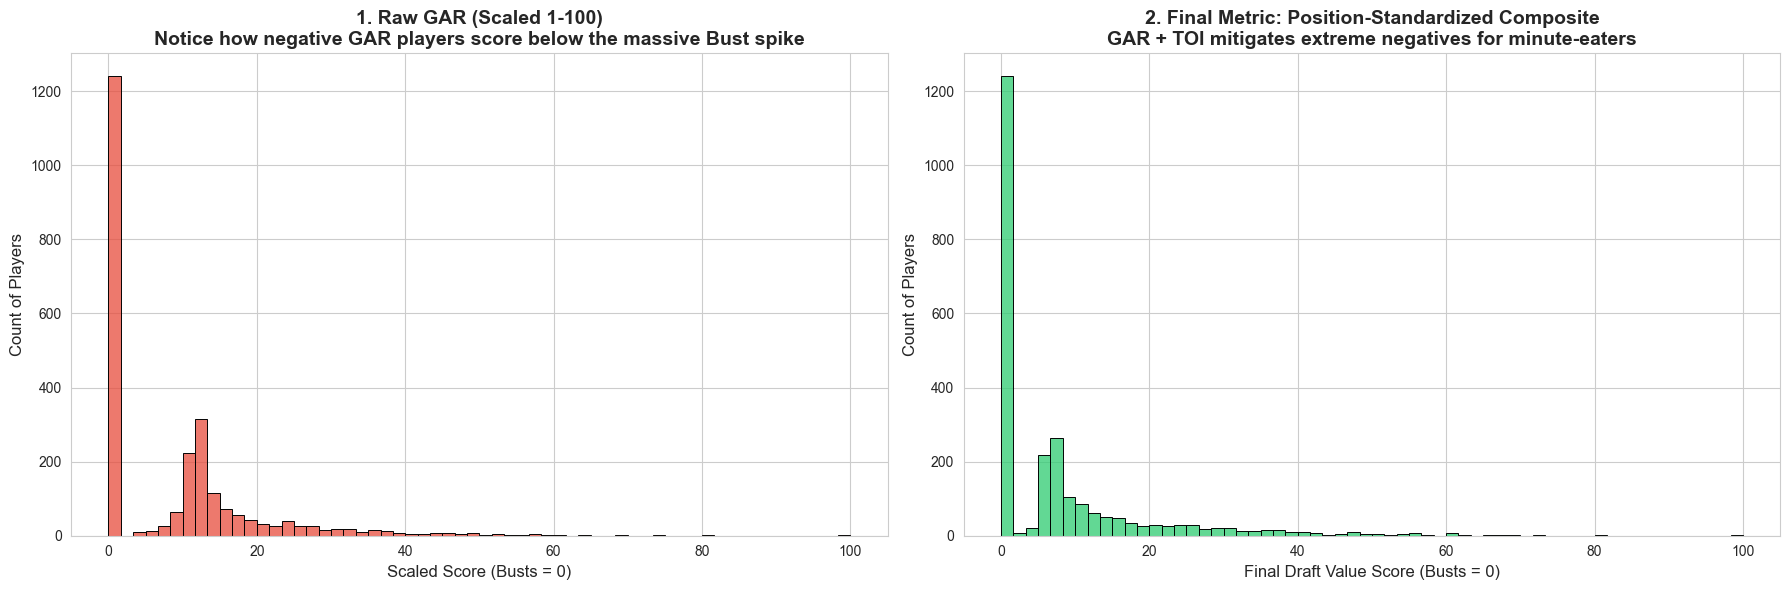

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

print("="*70)
print("REPORT: TOP AND BOTTOM 10 PICKS (BEFORE VS AFTER)")
print("="*70)

# 1. BEFORE Normalization (Raw GAR)
print("\n--- BEFORE: Top 10 by Raw GAR ---")
top_raw = df_final.nlargest(10, 'gar_total_raw')[['player_name', 'pos_group', 'gar_total_raw', 'toi_aggregated']]
print(top_raw.to_string(index=False))

print("\n--- BEFORE: Bottom 10 NHLers by Raw GAR (Actively Harmful) ---")
# Filtering to Group A so we see the actual worst NHLers, not just the 0.0 busts
bottom_raw = df_final[df_final['group_type'] == 'A'].nsmallest(10, 'gar_total_raw')[['player_name', 'pos_group', 'gar_total_raw', 'toi_aggregated']]
print(bottom_raw.to_string(index=False))

# 2. AFTER Normalization (Position-Standardized Composite)
print("\n" + "-"*50)
print("\n--- AFTER: Top 10 by Final Normalized Metric ---")
top_norm = df_final.nlargest(10, 'draft_value_normalized')[['player_name', 'pos_group', 'gar_total_raw', 'toi_aggregated', 'draft_value_normalized']]
print(top_norm.to_string(index=False))

print("\n--- AFTER: Bottom 10 NHLers by Final Normalized Metric ---")
# Filtering to Group A to show who scores closest to the absolute bust floor (0.0)
bottom_norm = df_final[df_final['group_type'] == 'A'].nsmallest(10, 'draft_value_normalized')[['player_name', 'pos_group', 'gar_total_raw', 'toi_aggregated', 'draft_value_normalized']]
print(bottom_norm.to_string(index=False))

# 3. Histograms
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Raw GAR Scaled 1-100
sns.histplot(data=df_final, x='gar_raw_scaled', bins=60, ax=axes[0], color='#e74c3c', edgecolor='black')
axes[0].set_title("1. Raw GAR (Scaled 1-100)\nNotice how negative GAR players score below the massive Bust spike", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Scaled Score (Busts = 0)", fontsize=12)
axes[0].set_ylabel("Count of Players", fontsize=12)

# Plot 2: Position-Standardized Composite
sns.histplot(data=df_final, x='draft_value_normalized', bins=60, ax=axes[1], color='#2ecc71', edgecolor='black')
axes[1].set_title("2. Final Metric: Position-Standardized Composite\nGAR + TOI mitigates extreme negatives for minute-eaters", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Final Draft Value Score (Busts = 0)", fontsize=12)
axes[1].set_ylabel("Count of Players", fontsize=12)

plt.tight_layout()
plt.show()

## SECTION 3: DATA DIAGNOSTICS AND PLAYER PREVIEWS

Verify data integrity and show top/bottom performers by GAR before building the model.

In [8]:
print("\n" + "="*70)
print("SECTION 3: DATA DIAGNOSTICS AND PLAYER PREVIEWS")
print("="*70)

print(f"\n1. Dataset structure:")
print(f"   - Total picks: {len(df_final):,}")
print(f"   - Group A (performers): {(df_final['group_type'] == 'A').sum():,}")
print(f"   - Group B (busts): {(df_final['group_type'] == 'B').sum():,}")

group_a = df_final[df_final['group_type'] == 'A']

print(f"\n2. Raw GAR distribution (Group A only):")
print(f"   - Min: {group_a['gar_total_raw'].min():.1f}")
print(f"   - Q1: {group_a['gar_total_raw'].quantile(0.25):.1f}")
print(f"   - Median: {group_a['gar_total_raw'].median():.1f}")
print(f"   - Mean: {group_a['gar_total_raw'].mean():.1f}")
print(f"   - Q3: {group_a['gar_total_raw'].quantile(0.75):.1f}")
print(f"   - Max: {group_a['gar_total_raw'].max():.1f}")

print(f"\n3. Final 'draft_value_normalized' distribution (Group A only):")
print(f"   - Min: {group_a['draft_value_normalized'].min():.1f}")
print(f"   - Q1: {group_a['draft_value_normalized'].quantile(0.25):.1f}")
print(f"   - Median: {group_a['draft_value_normalized'].median():.1f}")
print(f"   - Mean: {group_a['draft_value_normalized'].mean():.1f}")
print(f"   - Q3: {group_a['draft_value_normalized'].quantile(0.75):.1f}")
print(f"   - Max: {group_a['draft_value_normalized'].max():.1f}")

print(f"\n4. Top 10 performers by Final Draft Value (draft_value_normalized):")
top_performers = group_a.nlargest(10, 'draft_value_normalized')[
    ['player_name', 'pos_group', 'draft_year', 'overall', 'gar_total_raw', 'toi_aggregated', 'draft_value_normalized']
]
for idx, row in top_performers.iterrows():
    print(f"   - {row['player_name']:25s} ({row['pos_group']}, {row['draft_year']}, #{row['overall']:<3.0f}): Final_Val={row['draft_value_normalized']:6.1f} | Raw_GAR={row['gar_total_raw']:5.1f} | TOI={row['toi_aggregated']:7.0f}")

print(f"\n5. Bottom 10 performers by Final Draft Value (Group A only):")
bottom_performers = group_a.nsmallest(10, 'draft_value_normalized')[
    ['player_name', 'pos_group', 'draft_year', 'overall', 'gar_total_raw', 'toi_aggregated', 'draft_value_normalized']
]
for idx, row in bottom_performers.iterrows():
    print(f"   - {row['player_name']:25s} ({row['pos_group']}, {row['draft_year']}, #{row['overall']:<3.0f}): Final_Val={row['draft_value_normalized']:6.1f} | Raw_GAR={row['gar_total_raw']:5.1f} | TOI={row['toi_aggregated']:7.0f}")

print(f"\n6. Top 25 Highest Drafted Busts (Group B - Final Draft Value is strictly 0.0):")
highest_busts = df_final[df_final['group_type'] == 'B'].nsmallest(25, 'overall')[
    ['player_name', 'draft_year', 'overall', 'draft_value_normalized']
]
for idx, row in highest_busts.iterrows():
    print(f"   - {row['player_name']:25s} ({row['draft_year']}, #{row['overall']:<3.0f}) - Final_Val: {row['draft_value_normalized']:.1f}")
    
print(f"\n✓ Section 3 complete")


SECTION 3: DATA DIAGNOSTICS AND PLAYER PREVIEWS

1. Dataset structure:
   - Total picks: 2,475
   - Group A (performers): 1,235
   - Group B (busts): 1,240

2. Raw GAR distribution (Group A only):
   - Min: -20.1
   - Q1: -0.5
   - Median: 2.0
   - Mean: 10.4
   - Q3: 14.2
   - Max: 163.6

3. Final 'draft_value_normalized' distribution (Group A only):
   - Min: 1.0
   - Q1: 6.8
   - Median: 10.0
   - Mean: 15.8
   - Q3: 20.3
   - Max: 100.0

4. Top 10 performers by Final Draft Value (draft_value_normalized):
   - Connor McDavid            (F, 2015, #1  ): Final_Val= 100.0 | Raw_GAR=163.6 | TOI=  10536
   - Auston Matthews           (F, 2016, #1  ): Final_Val=  81.4 | Raw_GAR=127.3 | TOI=   9425
   - Elias Pettersson          (F, 2017, #5  ): Final_Val=  72.8 | Raw_GAR=114.7 | TOI=   7780
   - Matthew Tkachuk           (F, 2016, #6  ): Final_Val=  71.7 | Raw_GAR=107.7 | TOI=   9057
   - Nathan MacKinnon          (F, 2013, #1  ): Final_Val=  69.2 | Raw_GAR= 97.8 | TOI=  10256
   - Quinn

## SECTION 4: GENERATE B-SPLINE BASIS FUNCTIONS WITH NEW KNOTS

Create cubic B-spline basis with manually-specified knots: internal=[5, 15, 30, 50, 100, 150, 200], boundary=[1, 210].

In [9]:
from patsy import dmatrix
import numpy as np

print("\n" + "="*70)
print("SECTION 4: GENERATING B-SPLINE BASIS FUNCTIONS")
print("="*70)

# Prepare training data: Use only picks 1-210
print(f"\n1. Preparing training data from picks 1-210 only...")
df_train = df_final[df_final['overall'] <= 210].copy()
df_train = df_train.sort_values('overall').reset_index(drop=True)

# Use overall as X, draft_value_normalized as y
X = df_train['overall'].values.astype(float)
y = df_train['draft_value_normalized'].values

picks_used = len(df_train)
print(f"   - Training picks (1-210): {picks_used:,}")
print(f"     Group A performers: {(df_train['group_type'] == 'A').sum():,}")
print(f"     Group B busts: {(df_train['group_type'] == 'B').sum():,}")
print(f"   - Excluded picks (211-217): {(df_final['overall'] > 210).sum():,} (small sample, will use pick 210 value)")
print(f"   - X (overall) range: {X.min():.0f} to {X.max():.0f}")
print(f"   - y (draft_value_normalized) range: {y.min():.1f} to {y.max():.1f}")
print(f"   - Non-zero values (Group A): {(y > 0).sum():,}")
print(f"   - Zero values (Group B): {(y == 0).sum():,}")

# Generate B-spline basis with manually specified knots
print(f"\n2. Generating cubic B-spline basis with adaptive knots...")
internal_knots = [5, 15, 30, 50, 100, 150, 200]  # 7 internal knots
boundary_knots = [1, 210]  # Explicitly set to match training range
print(f"   - Internal knots: {internal_knots}")
print(f"   - Boundary knots: {boundary_knots}")
print(f"   - Rationale:")
print(f"     * 5: Early round threshold (picks 1-5 are elite)")
print(f"     * 15: End of round 1 (picks 6-15, still high impact)")
print(f"     * 30: End of round 1 in 32-team draft era")
print(f"     * 50: Early round 2 breakpoint")
print(f"     * 100: Mid-draft plateau")
print(f"     * 150: Late-draft zone")
print(f"     * 200: Near boundary (predictions will be most stable here)")

B_matrix = dmatrix(
    f"bs(x, knots={internal_knots}, degree=3, include_intercept=True, lower_bound={boundary_knots[0]}, upper_bound={boundary_knots[1]}) - 1",
    {"x": X}
)
design_info = B_matrix.design_info
B = np.asarray(B_matrix)

print(f"\n3. Basis matrix properties:")
print(f"   - Shape: {B.shape}")
print(f"   - Basis functions: {B.shape[1]}")
print(f"   - All values non-negative: {(B >= 0).all()}")

print(f"\n✓ Section 4 complete - basis functions ready for modeling")


SECTION 4: GENERATING B-SPLINE BASIS FUNCTIONS

1. Preparing training data from picks 1-210 only...
   - Training picks (1-210): 2,451
     Group A performers: 1,233
     Group B busts: 1,218
   - Excluded picks (211-217): 24 (small sample, will use pick 210 value)
   - X (overall) range: 1 to 210
   - y (draft_value_normalized) range: 0.0 to 100.0
   - Non-zero values (Group A): 1,233
   - Zero values (Group B): 1,218

2. Generating cubic B-spline basis with adaptive knots...
   - Internal knots: [5, 15, 30, 50, 100, 150, 200]
   - Boundary knots: [1, 210]
   - Rationale:
     * 5: Early round threshold (picks 1-5 are elite)
     * 15: End of round 1 (picks 6-15, still high impact)
     * 30: End of round 1 in 32-team draft era
     * 50: Early round 2 breakpoint
     * 100: Mid-draft plateau
     * 150: Late-draft zone
     * 200: Near boundary (predictions will be most stable here)

3. Basis matrix properties:
   - Shape: (2451, 11)
   - Basis functions: 11
   - All values non-nega

## SECTION 5: BAYESIAN MONOTONIC B-SPLINE MODEL WITH ADAPTIVE STEP PRIORS

Build PyMC3 model with adaptive step priors:
- **High variance for first 4 steps** (picks 1-30): σ/2 for sharp early-draft drops
- **Low variance for remaining steps** (picks 30+): σ/20 for smoothness in later rounds

In [10]:
import pytensor.tensor as pt
import pymc as pm
import numpy as np

print("\n" + "="*70)
print("SECTION 5: BUILDING BAYESIAN MONOTONIC B-SPLINE MODEL")
print("="*70)

# 1. Calculate dynamic priors from the FULL training dataset (including busts)
# The max of the dataset is our starting anchor (Pick 1)
prior_mu_start = np.max(y) if len(y) > 0 else 100.0
# The standard deviation of the entire dataset dictates our step variance budget
prior_sigma = np.std(y) if len(y) > 0 else 1.0

print(f"\n1. Data statistics for adaptive priors (Full Dataset):")
print(f"   - Max draft_value_normalized (Pick 1 Anchor): {prior_mu_start:,.2f}")
print(f"   - Std draft_value_normalized (Variance Budget): {prior_sigma:,.2f}")
print(f"   - Dataset mean (includes busts): {np.mean(y):.2f}")

# 2. Build adaptive step priors (CRITICAL INNOVATION)
n_basis = B.shape[1]
n_steps = n_basis - 1
step_priors = np.zeros(n_steps)

# High variance for first 4 steps (picks 1-30): allow sharp drops at top of draft
step_priors[:4] = prior_sigma / 2
# Low variance for remaining steps (picks 30+): enforce smoothness
step_priors[4:] = prior_sigma / 20

print(f"\n2. Building adaptive step priors...")
print(f"   - Total steps: {n_steps}")
print(f"   - First 4 steps (picks 1-30) std: {step_priors[:4].mean():.3f} (high variance, sharp drops allowed)")
print(f"   - Remaining steps (picks 30+) std: {step_priors[4:].mean():.3f} (low variance, smooth curve)")
print(f"   - Variance ratio (early/late): {step_priors[:4].mean() / step_priors[4:].mean():.1f}x")

print(f"\n3. Model specification:")
print(f"   - Prior for sigma (noise): HalfNormal(σ={prior_sigma:.1f})")
print(f"   - Prior for intercept beta_0: HalfNormal(σ={prior_mu_start:.1f})")
print(f"   - Prior for steps: HalfNormal(σ=step_priors array) [ADAPTIVE]")
print(f"   - Monotonicity: Strictly decreasing via cumsum of positive steps")
print(f"   - Floor constraint: All betas >= 0 (curve stays non-negative)")

with pm.Model() as gar_spline_model:
    # Noise standard deviation
    sigma = pm.HalfNormal("sigma", sigma=prior_sigma)
    
    # Intercept (The expected value of Pick #1)
    beta_0 = pm.HalfNormal("beta_0", sigma=prior_mu_start)
    
    # Adaptive step priors: high variance for early steps, low for late
    steps = pm.HalfNormal("steps", sigma=step_priors, shape=n_steps)
    
    # Build coefficient vector: monotonically decreasing
    # Mathematically: betas = beta_0 - [0, step_1, step_1 + step_2, ...]
    zeros = pt.zeros(1) # Safe PyTensor 1D zero array
    cumulative_steps = pm.math.concatenate([zeros, pm.math.cumsum(steps)])
    
    # Subtract cumulative steps from the intercept to force a downward trajectory
    betas_full = beta_0 - cumulative_steps
    
    # Clamp to ensure non-negative (Busts represent the absolute floor at 0)
    betas = pm.Deterministic("betas", pm.math.maximum(betas_full, 0))
    
    # Linear predictor (Dot product of Basis matrix and coefficients)
    mu = pm.Deterministic("mu", pm.math.dot(B, betas))
    
    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)
    
    print(f"\n4. Model components defined in PyMC:")
    print(f"   - sigma: HalfNormal(σ={prior_sigma:.1f})")
    print(f"   - beta_0: HalfNormal(σ={prior_mu_start:.1f})")
    print(f"   - steps: HalfNormal(σ=step_priors), shape {n_steps}")
    print(f"   - betas: {n_basis} coefficients (monotonic decreasing, floor at 0)")
    print(f"   - mu: B-spline prediction")
    print(f"   - y_obs: {len(y):,} observed values")
    print(f"\n   Training data: Full dataset (performers + imputed busts)")
    print(f"   - Group B busts at y=0 define the curve floor")
    print(f"   - Adaptive priors enforce sharp early drops + smooth later rounds")

print(f"\nModel specification complete. Ready for posterior sampling.")
print(f"\n✓ Section 5 complete")


SECTION 5: BUILDING BAYESIAN MONOTONIC B-SPLINE MODEL

1. Data statistics for adaptive priors (Full Dataset):
   - Max draft_value_normalized (Pick 1 Anchor): 100.00
   - Std draft_value_normalized (Variance Budget): 12.25
   - Dataset mean (includes busts): 7.94

2. Building adaptive step priors...
   - Total steps: 10
   - First 4 steps (picks 1-30) std: 6.124 (high variance, sharp drops allowed)
   - Remaining steps (picks 30+) std: 0.612 (low variance, smooth curve)
   - Variance ratio (early/late): 10.0x

3. Model specification:
   - Prior for sigma (noise): HalfNormal(σ=12.2)
   - Prior for intercept beta_0: HalfNormal(σ=100.0)
   - Prior for steps: HalfNormal(σ=step_priors array) [ADAPTIVE]
   - Monotonicity: Strictly decreasing via cumsum of positive steps
   - Floor constraint: All betas >= 0 (curve stays non-negative)

4. Model components defined in PyMC:
   - sigma: HalfNormal(σ=12.2)
   - beta_0: HalfNormal(σ=100.0)
   - steps: HalfNormal(σ=step_priors), shape 10
   - beta

## SECTION 6: POSTERIOR SAMPLING WITH NUTS (NUTPIE/JAX)

Sample 2000 draws from posterior using NUTS sampler. Verify convergence diagnostics.

In [11]:
import arviz as az
import pymc as pm

print("\n" + "="*70)
print("SECTION 6: POSTERIOR SAMPLING")
print("="*70)

print(f"\n1. NUTS sampler configuration (Nutpie - Rust Backend):")
print(f"   - Draws: 2000")
print(f"   - Tuning: 1000")
print(f"   - Chains: 4 (Maximized for CPU cores)")
print(f"   - Target accept: 0.90")

# Ensure the model context is active
with gar_spline_model:
    # Use Nutpie for massive compilation and sampling speedups
    idata = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,  # Upped to 4 to get a better posterior distribution
        cores=4,   
        nuts_sampler="nutpie",
        target_accept=0.90,
        random_seed=42,
        progressbar=True
    )

print(f"\n2. Sampling completed successfully")

print(f"\n3. Convergence diagnostics:")
# Calculate Gelman-Rubin statistic (R-hat)
rhat = az.rhat(idata)

# Extract max R-hat safely across all variables
rhat_max = max(v.max().item() for v in rhat.data_vars.values())
all_converged = rhat_max < 1.01

print(f"   - Max Rhat: {rhat_max:.4f}")
print(f"   - All Rhat < 1.01: {all_converged}")

if all_converged:
    print(f"   ✓ Strong convergence achieved! The chains mixed perfectly.")
else:
    print(f"   ⚠ WARNING: Some parameters have Rhat >= 1.01.")
    print(f"     The adaptive priors may be fighting the data. Consider increasing 'tune' to 2000.")

print(f"\n✓ Posterior sampling complete")


SECTION 6: POSTERIOR SAMPLING

1. NUTS sampler configuration (Nutpie - Rust Backend):
   - Draws: 2000
   - Tuning: 1000
   - Chains: 4 (Maximized for CPU cores)
   - Target accept: 0.90


Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.15,63
,3000,0,0.15,63
,3000,0,0.16,63
,3000,0,0.13,63



2. Sampling completed successfully

3. Convergence diagnostics:
   - Max Rhat: 1.0051
   - All Rhat < 1.01: True
   ✓ Strong convergence achieved! The chains mixed perfectly.

✓ Posterior sampling complete


## SECTION 7: EXTRACT AND NORMALIZE PREDICTIONS (PICK #1 = 100)

Generate predictions on full pick grid and normalize to Pick 1 baseline. Extend picks 211-300 with pick 210 value.

In [16]:
import numpy as np
from patsy import build_design_matrices

print("\n" + "="*70)
print("SECTION 7: EXTRACTING AND NORMALIZING PREDICTIONS")
print("="*70)
print("\nMetric: Position-Standardized Composite (70% GAR / 30% TOI)")
print("Trained on picks 1-210 (with adaptive step priors)")
print("Picks 211-300: Assigned value of pick 210 (insufficient sample)")

# Create prediction grid for trained range (1-210)
pick_grid_train = np.arange(1, 211, dtype=float)

print(f"\n1. Building prediction basis matrix for picks 1-210...")
# Uses the design_info saved from Section 4
B_grid_train = build_design_matrices([design_info], {"x": pick_grid_train})[0]
B_grid_train = np.asarray(B_grid_train)
print(f"   - Grid shape: {pick_grid_train.shape}")
print(f"   - Basis matrix shape: {B_grid_train.shape}")

# Extract posterior betas
print(f"\n2. Extracting posterior betas...")
posterior_betas = idata.posterior['betas'].values
print(f"   - Shape: {posterior_betas.shape}")

# Reshape for prediction
n_chains, n_draws, n_basis = posterior_betas.shape
posterior_betas_flat = posterior_betas.reshape(n_chains * n_draws, n_basis)
print(f"   - Flattened shape: {posterior_betas_flat.shape}")

# Generate predictions on training grid (1-210)
print(f"\n3. Generating posterior predictions for picks 1-210...")
mu_grid_samples = np.dot(B_grid_train, posterior_betas_flat.T).T
mu_mean = mu_grid_samples.mean(axis=0)
mu_std = mu_grid_samples.std(axis=0)
mu_hdi_3pct = np.percentile(mu_grid_samples, 3, axis=0)
mu_hdi_97pct = np.percentile(mu_grid_samples, 97, axis=0)

print(f"   - Predictions shape: {mu_grid_samples.shape}")
print(f"   - Mean draft_value_normalized range: {mu_mean.min():.2f} to {mu_mean.max():.2f}")

# Get pick 210 values for flattening the tail
idx_210 = np.argmin(np.abs(pick_grid_train - 210))
pick_210_value = mu_mean[idx_210]
pick_210_hdi_3 = mu_hdi_3pct[idx_210]
pick_210_hdi_97 = mu_hdi_97pct[idx_210]
print(f"   - Pick 210 raw prediction: {pick_210_value:.4f}")

# Extend to full grid (1-300)
pick_grid = np.arange(1, 301, dtype=float)

# Extend Mean
mu_mean_extended = np.zeros(300)
mu_mean_extended[:210] = mu_mean
mu_mean_extended[210:] = pick_210_value

# Extend HDIs
mu_hdi_3_extended = np.zeros(300)
mu_hdi_3_extended[:210] = mu_hdi_3pct
mu_hdi_3_extended[210:] = pick_210_hdi_3

mu_hdi_97_extended = np.zeros(300)
mu_hdi_97_extended[:210] = mu_hdi_97pct
mu_hdi_97_extended[210:] = pick_210_hdi_97

print(f"\n4. Normalizing to Pick 1 = 100 scale...")
pick_1_value = mu_mean[0]

if pick_1_value > 0:
    mu_normalized = 100 * mu_mean_extended / pick_1_value 
else:
    mu_normalized = mu_mean_extended

print(f"   - Pick 1 raw value: {pick_1_value:.2f}")
print(f"   - Pick 30 : {mu_mean_extended[29]:.1f}")
print(f"   - Pick 100 : {mu_mean_extended[99]:.1f}")
print(f"   - Pick 210 : {mu_mean_extended[209]:.1f}")
print(f"   - Pick 217 : {mu_mean_extended[216]:.1f} (assigned from pick 210)")

print(f"\n✓ Predictions extracted")
print(f"   Picks 1-210 from model, Picks 211-300 flattened to pick 210 value")


SECTION 7: EXTRACTING AND NORMALIZING PREDICTIONS

Metric: Position-Standardized Composite (70% GAR / 30% TOI)
Trained on picks 1-210 (with adaptive step priors)
Picks 211-300: Assigned value of pick 210 (insufficient sample)

1. Building prediction basis matrix for picks 1-210...
   - Grid shape: (210,)
   - Basis matrix shape: (210, 11)

2. Extracting posterior betas...
   - Shape: (4, 2000, 11)
   - Flattened shape: (8000, 11)

3. Generating posterior predictions for picks 1-210...
   - Predictions shape: (8000, 210)
   - Mean draft_value_normalized range: 2.07 to 54.86
   - Pick 210 raw prediction: 2.0740

4. Normalizing to Pick 1 = 100 scale...
   - Pick 1 raw value: 54.86
   - Pick 30 : 11.4
   - Pick 100 : 5.4
   - Pick 210 : 2.1
   - Pick 217 : 2.1 (assigned from pick 210)

✓ Predictions extracted
   Picks 1-210 from model, Picks 211-300 flattened to pick 210 value


## SECTION 8: GENERATE CANONICAL LOOKUP TABLES

Create master lookup tables for picks 1-300 with total, offensive, and defensive GAR.

In [21]:
print("\n" + "="*70)
print("SECTION 8: GENERATING CANONICAL LOOKUP TABLES")
print("="*70)

print(f"\n1. Creating master lookup table for Draft Value (picks 1-300)...")

# Calculate normalized floor/ceiling (scaled relative to Pick 1 mean)
# Ensure we use the same scaling factor as the mean (pick_1_value)
if pick_1_value > 0:
    ceiling_normalized = 100 * mu_hdi_97_extended / pick_1_value
    floor_normalized = 100 * mu_hdi_3_extended / pick_1_value
else:
    ceiling_normalized = mu_hdi_97_extended
    floor_normalized = mu_hdi_3_extended

# Combine the mean and the HDI bounds into the final table
master_curve = pd.DataFrame({
    'overall': pick_grid.astype(int),
    'expected_draft_value': mu_normalized,      # Scaled so Pick 1 = 100
    'value_ceiling_97pct': ceiling_normalized,   # Scaled bounds
    'value_floor_3pct': floor_normalized,        # Scaled bounds
    'raw_model_output': mu_mean_extended,        # The pre-100-scaled model output
    'raw_floor_3pct': mu_hdi_3_extended,         # Pre-100-scaled pessimistic
    'raw_ceiling_97pct': mu_hdi_97_extended      # Pre-100-scaled optimistic
})

print(f"   - Rows: {len(master_curve):,}")
print(f"   - Columns: {list(master_curve.columns)}")

print(f"\n2. Sample predictions (Top 10 & Notable Picks):")
# View key milestones in the draft to ensure the drop-off makes sense
notable_picks = [1, 2, 3, 10, 15, 32, 50, 100, 150, 200, 217]
print(master_curve[master_curve['overall'].isin(notable_picks)].to_string(index=False))

print(f"\n3. Saving lookup table...")

# Save the master lookup table to your export directory
# (Make sure export_dir is defined, usually it's base_dir / 'Processed' or similar)
lookup_path = export_dir / 'draft_curve_gar_composite_lookup.csv'
master_curve.to_csv(lookup_path, index=False)

print(f"   ✓ Saved Canonical Draft Curve: {lookup_path}")

print(f"\n✓ Section 8 complete - Lookup table ready for Trade Analyzer integration.")


SECTION 8: GENERATING CANONICAL LOOKUP TABLES

1. Creating master lookup table for Draft Value (picks 1-300)...
   - Rows: 300
   - Columns: ['overall', 'expected_draft_value', 'value_ceiling_97pct', 'value_floor_3pct', 'raw_model_output', 'raw_floor_3pct', 'raw_ceiling_97pct']

2. Sample predictions (Top 10 & Notable Picks):
 overall  expected_draft_value  value_ceiling_97pct  value_floor_3pct  raw_model_output  raw_floor_3pct  raw_ceiling_97pct
       1            100.000000           107.450794         92.359039         54.859209       50.667438          58.946655
       2             80.094796            84.533205         75.688409         43.939371       41.522062          46.374247
       3             68.407108            72.853153         63.951337         37.527598       35.083197          39.966663
      10             47.725446            50.614600         44.860825         26.181802       24.610293          27.766769
      15             39.374784            41.687762     


SECTION 8.5: COMPOSITE DRAFT VALUE CURVE WITH SCATTERPOINTS


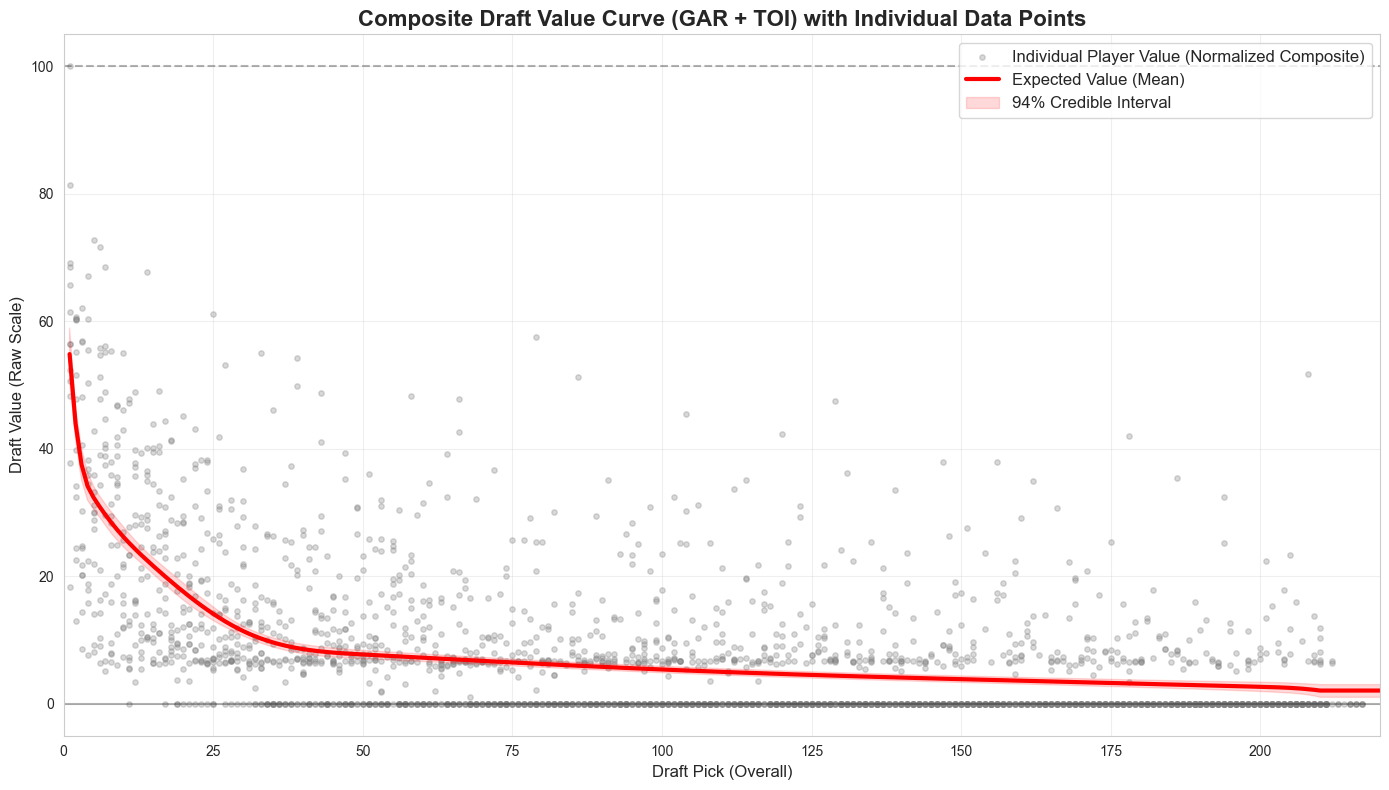

In [28]:
print("\n" + "="*70)
print("SECTION 8.5: COMPOSITE DRAFT VALUE CURVE WITH SCATTERPOINTS")
print("="*70)

import matplotlib.pyplot as plt

# Filter input data for the scatter plot (Group A: have GAR data)
# Use df_final_dataset which contains the 'draft_value_normalized' calculated in Section 2.5
scatter_data = df_final_dataset

plt.figure(figsize=(14, 8))

# 1. Plot Individual Picks (Scatter - Normalized Composite)
# using the 'draft_value_normalized' column which is the target variable for the model
plt.scatter(
    scatter_data['overall'], 
    scatter_data['draft_value_normalized'], 
    alpha=0.3, 
    s=15, 
    color='gray', 
    label='Individual Player Value (Normalized Composite)'
)

# 2. Plot Normalized Model Curve (Mean)
plt.plot(
    master_curve['overall'], 
    master_curve['raw_model_output'],  # Using the raw model output for the mean curve
    color='red', 
    linewidth=3, 
    label='Expected Value (Mean)'
)

# 3. Plot Normalized Confidence Bands
plt.fill_between(
    master_curve['overall'], 
    master_curve['raw_floor_3pct'], 
    master_curve['raw_ceiling_97pct'], 
    color='red', 
    alpha=0.15, 
    label='94% Credible Interval'
)

# Formatting
plt.title('Composite Draft Value Curve (GAR + TOI) with Individual Data Points', fontsize=16, fontweight='bold')
plt.xlabel('Draft Pick (Overall)', fontsize=12)
plt.ylabel('Draft Value (Raw Scale)', fontsize=12)
plt.axhline(100, color='black', linestyle='--', alpha=0.3)
plt.axhline(0, color='black', linestyle='-', alpha=0.3)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, alpha=0.3)
plt.xlim(0, 220)

plt.tight_layout()
plt.show()

## SECTION 9: LOAD & COMPARE FOUR CURVES (GAR vs. GPM vs. TRUTH vs. TOI)

Load pre-computed Truth Score, TOI, and reuse GPM curves. Merge all four on overall and compare.

In [22]:
print("\n" + "="*70)
print("SECTION 9: FOUR-CURVE COMPARISON")
print("="*70)

# Load previously generated curves
curves_path = base_dir / 'data' / 'prior_results' / 'all_four_metrics_spline_predictions.csv'

print(f"\n1. Loading consolidated curves from {curves_path}...")

if curves_path.exists():
    external_curves = pd.read_csv(curves_path)
    if 'pick_number' in external_curves.columns:
        external_curves = external_curves.rename(columns={'pick_number': 'overall'})
    print(f"   ✓ Loaded external curves: {len(external_curves):,} picks")
    print(f"   - Columns: {external_curves.columns.tolist()}")
else:
    print(f"   ✗ Curve file not found: {curves_path}")
    external_curves = None

# Merge all curves using our new Composite curve as the base
print(f"\n2. Merging curves on overall pick...")

comparison_df = master_curve[['overall', 'expected_draft_value']].copy()
comparison_df.columns = ['overall', 'gar_composite']

if external_curves is not None:
    # Select specific normalized columns 
    # Using 'gpm_normalized' for the GPM/RAPM comparison based on file structure
    cols_to_merge = ['overall']
    if 'truth_normalized' in external_curves.columns:
        cols_to_merge.append('truth_normalized')
    if 'toi_normalized' in external_curves.columns:
        cols_to_merge.append('toi_normalized')
    if 'gpm_normalized' in external_curves.columns:
        external_curves = external_curves.rename(columns={'gpm_normalized': 'gpm_rapm'})
        cols_to_merge.append('gpm_rapm')
    elif 'xgpm_normalized' in external_curves.columns:
        # Fallback if gpm_normalized isn't the target
        external_curves = external_curves.rename(columns={'xgpm_normalized': 'gpm_rapm'})
        cols_to_merge.append('gpm_rapm')

    comparison_df = comparison_df.merge(
        external_curves[cols_to_merge],
        on='overall',
        how='left'
    )
    print(f"   - Merged external metrics: {[c for c in cols_to_merge if c != 'overall']}")

print(f"   ✓ Merged {len(comparison_df):,} picks")

print(f"\n3. Curve Comparison Summary (Key Picks):")
print(f"{'Pick':<8} {'GAR Comp':<12} {'GPM (RAPM)':<12} {'Truth':<12} {'TOI':<12}")
print("-" * 60)

for pick in [1, 5, 10, 15, 20, 25, 30, 50, 100, 150, 210]:
    if pick <= comparison_df['overall'].max():
        row = comparison_df[comparison_df['overall'] == pick]
        if len(row) > 0:
            gar_val = row['gar_composite'].values[0] if 'gar_composite' in row.columns else None
            gpm_val = row['gpm_rapm'].values[0] if 'gpm_rapm' in row.columns else None
            truth_val = row['truth_normalized'].values[0] if 'truth_normalized' in row.columns else None
            toi_val = row['toi_normalized'].values[0] if 'toi_normalized' in row.columns else None
            
            gar_str = f"{gar_val:.1f}" if pd.notnull(gar_val) else "N/A"
            gpm_str = f"{gpm_val:.1f}" if pd.notnull(gpm_val) else "N/A"
            truth_str = f"{truth_val:.1f}" if pd.notnull(truth_val) else "N/A"
            toi_str = f"{toi_val:.1f}" if pd.notnull(toi_val) else "N/A"
            
            print(f"{pick:<8} {gar_str:<12} {gpm_str:<12} {truth_str:<12} {toi_str:<12}")

print(f"\n✓ Curve comparison complete")


SECTION 9: FOUR-CURVE COMPARISON

1. Loading consolidated curves from x:\My Files\Kings\GAR_Only_Project\data\prior_results\all_four_metrics_spline_predictions.csv...
   ✓ Loaded external curves: 300 picks
   - Columns: ['overall', 'truth_raw', 'truth_normalized', 'toi_raw', 'toi_normalized', 'xgpm_raw', 'xgpm_normalized', 'gpm_raw', 'gpm_normalized']

2. Merging curves on overall pick...
   - Merged external metrics: ['truth_normalized', 'toi_normalized', 'gpm_rapm']
   ✓ Merged 300 picks

3. Curve Comparison Summary (Key Picks):
Pick     GAR Comp     GPM (RAPM)   Truth        TOI         
------------------------------------------------------------
1        100.0        100.0        100.0        100.0       
5        59.0         57.8         64.1         82.2        
10       47.7         47.9         50.0         68.0        
15       39.4         40.1         39.7         56.7        
20       32.1         34.0         32.9         47.1        
25       25.7         27.1         

## SECTION 10: VISUALIZE FOUR-CURVE COMPARISON (PICK #1 = 100)


SECTION 10: FOUR-CURVE COMPARISON VISUALIZATION


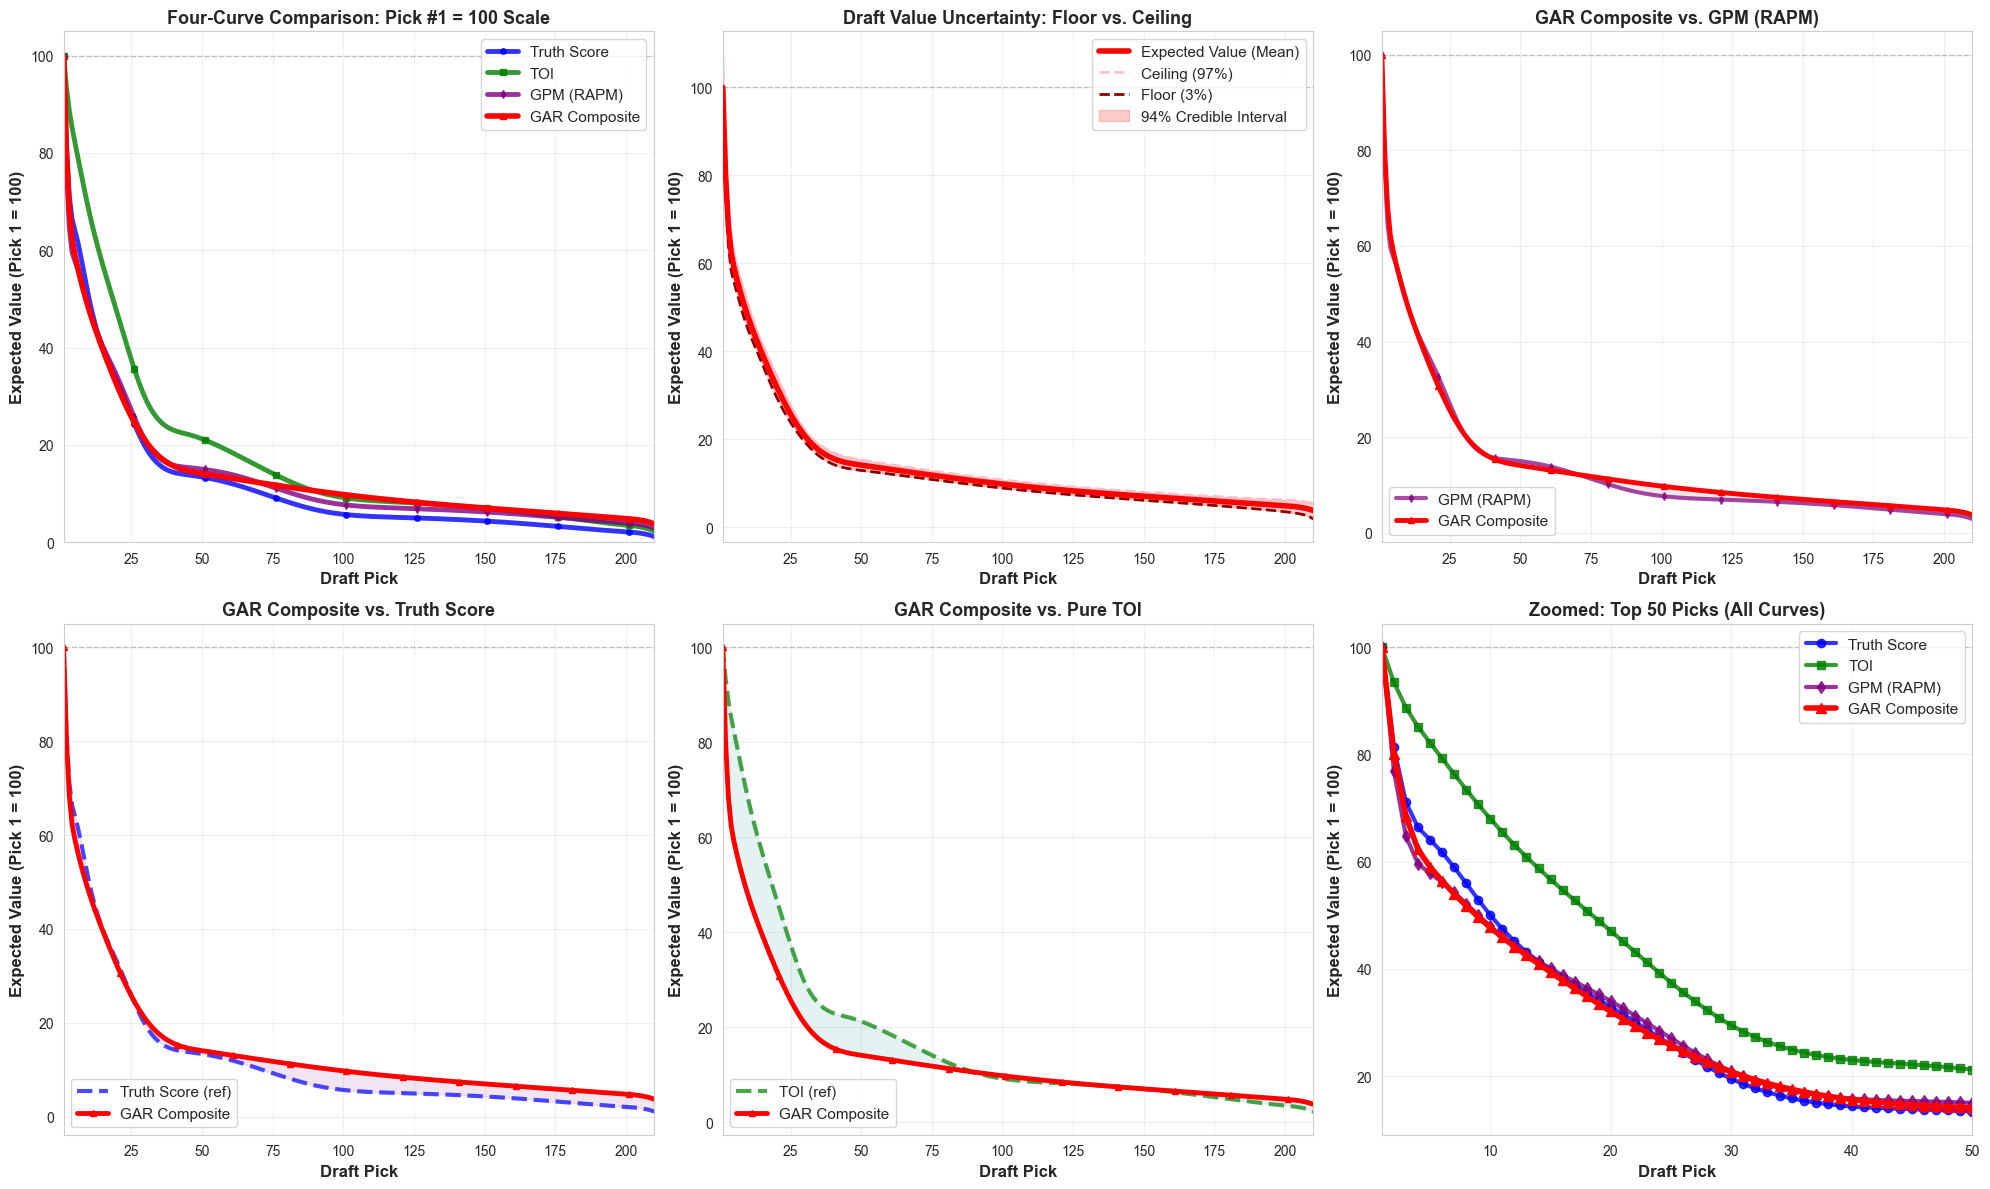


✓ Comparison visualization saved: x:\My Files\Kings\GAR_Only_Project\results\gar_curve\gar_four_curve_comparison.png

✓ Section 10 complete


In [23]:
import matplotlib.pyplot as plt

print("\n" + "="*70)
print("SECTION 10: FOUR-CURVE COMPARISON VISUALIZATION")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Panel 1: All four curves on same scale
ax = axes[0, 0]
if 'truth_normalized' in comparison_df.columns:
    ax.plot(comparison_df['overall'], comparison_df['truth_normalized'], 'b-', linewidth=3.5, label='Truth Score', marker='o', markersize=4, markevery=25, alpha=0.8)
if 'toi_normalized' in comparison_df.columns:
    ax.plot(comparison_df['overall'], comparison_df['toi_normalized'], 'g-', linewidth=3.5, label='TOI', marker='s', markersize=4, markevery=25, alpha=0.8)
if 'gpm_rapm' in comparison_df.columns:
    ax.plot(comparison_df['overall'], comparison_df['gpm_rapm'], 'purple', linewidth=3.5, label='GPM (RAPM)', marker='d', markersize=4, markevery=25, alpha=0.8)

ax.plot(comparison_df['overall'], comparison_df['gar_composite'], 'red', linewidth=4, label='GAR Composite', marker='^', markersize=5, markevery=25)
ax.axhline(100, color='black', linestyle='--', alpha=0.2, linewidth=1)
ax.set_xlabel('Draft Pick', fontweight='bold', fontsize=12)
ax.set_ylabel('Expected Value (Pick 1 = 100)', fontweight='bold', fontsize=12)
ax.set_title('Four-Curve Comparison: Pick #1 = 100 Scale', fontweight='bold', fontsize=13)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim([1, 210])
ax.set_ylim([0, 105])

# Panel 2: GAR Composite - Floor vs Ceiling (HDI Bands)
ax = axes[0, 1]
ax.plot(master_curve['overall'], master_curve['expected_draft_value'], 'red', linewidth=4, label='Expected Value (Mean)', zorder=3)
ax.plot(master_curve['overall'], master_curve['value_ceiling_97pct'], 'pink', linewidth=2, linestyle='--', label='Ceiling (97%)', zorder=2)
ax.plot(master_curve['overall'], master_curve['value_floor_3pct'], 'darkred', linewidth=2, linestyle='--', label='Floor (3%)', zorder=2)

ax.fill_between(master_curve['overall'], master_curve['value_floor_3pct'], master_curve['value_ceiling_97pct'], alpha=0.2, color='red', label='94% Credible Interval', zorder=1)

ax.axhline(100, color='black', linestyle='--', alpha=0.2, linewidth=1)
ax.set_xlabel('Draft Pick', fontweight='bold', fontsize=12)
ax.set_ylabel('Expected Value (Pick 1 = 100)', fontweight='bold', fontsize=12)
ax.set_title('Draft Value Uncertainty: Floor vs. Ceiling', fontweight='bold', fontsize=13)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim([1, 210])

# Panel 3: GAR vs GPM
ax = axes[0, 2]
if 'gpm_rapm' in comparison_df.columns:
    ax.plot(comparison_df['overall'], comparison_df['gpm_rapm'], 'purple', linewidth=3, label='GPM (RAPM)', marker='d', markersize=4, markevery=20, alpha=0.7)
ax.plot(comparison_df['overall'], comparison_df['gar_composite'], 'red', linewidth=3.5, label='GAR Composite', marker='^', markersize=5, markevery=20)
if 'gpm_rapm' in comparison_df.columns:
    ax.fill_between(comparison_df['overall'], comparison_df['gpm_rapm'], comparison_df['gar_composite'], alpha=0.1, color='brown')
ax.axhline(100, color='black', linestyle='--', alpha=0.2, linewidth=1)
ax.set_xlabel('Draft Pick', fontweight='bold', fontsize=12)
ax.set_ylabel('Expected Value (Pick 1 = 100)', fontweight='bold', fontsize=12)
ax.set_title('GAR Composite vs. GPM (RAPM)', fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([1, 210])

# Panel 4: GAR vs Truth Score
ax = axes[1, 0]
if 'truth_normalized' in comparison_df.columns:
    ax.plot(comparison_df['overall'], comparison_df['truth_normalized'], 'b--', linewidth=3, label='Truth Score (ref)', alpha=0.7)
ax.plot(comparison_df['overall'], comparison_df['gar_composite'], 'red', linewidth=3.5, label='GAR Composite', marker='^', markersize=5, markevery=20)
if 'truth_normalized' in comparison_df.columns:
    ax.fill_between(comparison_df['overall'], comparison_df['truth_normalized'], comparison_df['gar_composite'], alpha=0.1, color='purple')
ax.axhline(100, color='black', linestyle='--', alpha=0.2, linewidth=1)
ax.set_xlabel('Draft Pick', fontweight='bold', fontsize=12)
ax.set_ylabel('Expected Value (Pick 1 = 100)', fontweight='bold', fontsize=12)
ax.set_title('GAR Composite vs. Truth Score', fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([1, 210])

# Panel 5: GAR vs TOI
ax = axes[1, 1]
if 'toi_normalized' in comparison_df.columns:
    ax.plot(comparison_df['overall'], comparison_df['toi_normalized'], 'g--', linewidth=3, label='TOI (ref)', alpha=0.7)
ax.plot(comparison_df['overall'], comparison_df['gar_composite'], 'red', linewidth=3.5, label='GAR Composite', marker='^', markersize=5, markevery=20)
if 'toi_normalized' in comparison_df.columns:
    ax.fill_between(comparison_df['overall'], comparison_df['toi_normalized'], comparison_df['gar_composite'], alpha=0.1, color='teal')
ax.axhline(100, color='black', linestyle='--', alpha=0.2, linewidth=1)
ax.set_xlabel('Draft Pick', fontweight='bold', fontsize=12)
ax.set_ylabel('Expected Value (Pick 1 = 100)', fontweight='bold', fontsize=12)
ax.set_title('GAR Composite vs. Pure TOI', fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim([1, 210])

# Panel 6: Top 50 picks zoomed
ax = axes[1, 2]
top_50 = comparison_df[comparison_df['overall'] <= 50]
if 'truth_normalized' in top_50.columns:
    ax.plot(top_50['overall'], top_50['truth_normalized'], 'b-', linewidth=3, label='Truth Score', marker='o', markersize=6, alpha=0.8)
if 'toi_normalized' in top_50.columns:
    ax.plot(top_50['overall'], top_50['toi_normalized'], 'g-', linewidth=3, label='TOI', marker='s', markersize=6, alpha=0.8)
if 'gpm_rapm' in top_50.columns:
    ax.plot(top_50['overall'], top_50['gpm_rapm'], 'purple', linewidth=3, label='GPM (RAPM)', marker='d', markersize=6, alpha=0.8)

ax.plot(top_50['overall'], top_50['gar_composite'], 'red', linewidth=4, label='GAR Composite', marker='^', markersize=7)
ax.axhline(100, color='black', linestyle='--', alpha=0.2, linewidth=1)
ax.set_xlabel('Draft Pick', fontweight='bold', fontsize=12)
ax.set_ylabel('Expected Value (Pick 1 = 100)', fontweight='bold', fontsize=12)
ax.set_title('Zoomed: Top 50 Picks (All Curves)', fontweight='bold', fontsize=13)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim([1, 50])

plt.tight_layout()
viz_path = export_dir / 'gar_four_curve_comparison.png'
plt.savefig(viz_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Comparison visualization saved: {viz_path}")
print(f"\n✓ Section 10 complete")

## FINAL SUMMARY

Notebook execution complete. All artifacts saved.